# Housing Prices Regression - Sprint 02
Grupo 03 - Augusto, Gustavo Cortelassi, Heloisa Hartmann, Igor Costa e João Vogel



##Seção 1 - Revisão da sprint 01

### Contextualização e Alinhamento do Projeto
Na Sprint 1, explorámos um dataset de precificação imobiliária com o objetivo de mapear os fatores que mais impactam o valor dos imóveis. Os principais achados da nossa Análise Exploratória de Dados (EDA) foram:
* A coluna `ID` serve apenas como identificador único, constituindo ruído para os modelos preditivos.
* As variáveis `Has_Garden` e `Has_Pool` já se encontram no formato binário ideal (0 ou 1).
* Não foram identificados dados ausentes aparentes ou valores nulos disfarçados de zero nas colunas cruciais (`Price`, `Square_Feet`, `Num_Bedrooms`).
* `Square_Feet` (área do imóvel) e `Num_Bedrooms` (número de quartos) exibiram as correlações lineares mais fortes com o target Price.

### Ações Planeadas para esta Sprint 2:
1. Remover a coluna `ID` logo no carregamento inicial.
2. Isolar os conjuntos de Treino e Teste antes de qualquer transformação para mitigar o risco de *Data Leakage* (Vazamento de Dados).
3. Implementar Engenharia de Features para extrair a idade do imóvel (`Property_Age`) e um índice de acessibilidade baseado na localização e distância ao centro.
4. Construir um Pipeline robusto e reprodutível utilizando o `scikit-learn`.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url_github = 'https://raw.githubusercontent.com/heloshartmann/housing-prices-regression/refs/heads/main/real_estate_dataset.csv'
df_raw = pd.read_csv(url_github)

# Eliminação da coluna ID para evitar ruído preditivo
if 'ID' in df_raw.columns:
    df_raw = df_raw.drop(columns=['ID'])

print(f"Dataset carregado com sucesso. Formato inicial: {df_raw.shape}")
df_raw.head()

Dataset carregado com sucesso. Formato inicial: (500, 11)


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


## Seção 2 - Tratamento de dados ausentes

### Análise Prévia e Decisões Não Tomadas
Conforme validado na EDA, o dataset original não apresenta instâncias nulas (`NaN`). Avaliamos a hipótese de aplicar técnicas avançadas de imputação, tais como o `KNNImputer` ou o `IterativeImputer`. Contudo, optou-se por não aplicar nenhuma técnica de imputação, visto que a integridade dos registos é total (0\% de dados em falta). Implementamos uma verificação programática preventiva para garantir a consistência do Pipeline caso novos dados brutos entrem no fluxo futuramente.


In [13]:
# Diagnóstico por coluna
missing_by_col = df_raw.isnull().sum()
missing_pct_col = (df_raw.isnull().sum() / len(df_raw)) * 100

# Diagnóstico por linha (amostra das linhas com mais nulos, se houver)
missing_by_row = df_raw.isnull().sum(axis=1)

print("--- DIAGNÓSTICO DE VALORES AUSENTES POR COLUNA ---")
print(pd.DataFrame({'Total': missing_by_col, 'Percentual (%)': missing_pct_col}))

print(f"\nTotal de linhas com algum valor ausente: {(missing_by_row > 0).sum()}")

--- DIAGNÓSTICO DE VALORES AUSENTES POR COLUNA ---
                    Total  Percentual (%)
Square_Feet             0             0.0
Num_Bedrooms            0             0.0
Num_Bathrooms           0             0.0
Num_Floors              0             0.0
Year_Built              0             0.0
Has_Garden              0             0.0
Has_Pool                0             0.0
Garage_Size             0             0.0
Location_Score          0             0.0
Distance_to_Center      0             0.0
Price                   0             0.0

Total de linhas com algum valor ausente: 0


## Seção 3 - Tratamento de outliers

### Decisão Baseada em Regras de Negócio e Sensibilidade do Modelo
Variáveis de preço imobiliário costumam apresentar assimetria à direita devido a imóveis de alto padrão (outliers legítimos de mercado). Remover estes registos de forma purista enviesaria o modelo, impedindo-o de aprender a precificar propriedades de luxo.

### Estratégia Adotada:
1. Para as features preditivas contínuas: Utilizaremos o `RobustScaler` na etapa de escalonamento. Este método centraliza e dimensiona os dados com base nos quartis (IQR), neutralizando a distorção provocada por valores extremos sem eliminar informação.
2. Para a variável Target (`Price`): Demonstramos abaixo o impacto visual de uma Transformação Logarítmica (`np.log1p`). Esta técnica estabiliza a variância do preço e aproxima a distribuição de uma curva normal, o que melhora substancialmente a convergência de algoritmos de regressão linear e baseados em gradiente.


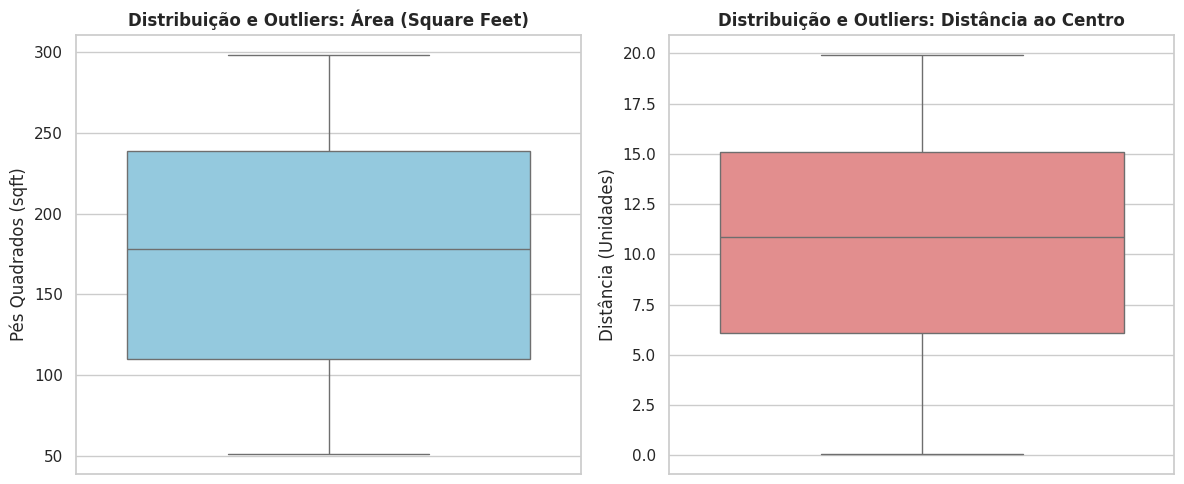

In [14]:
# Configuração do estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Boxplot para a Área do Imóvel
plt.subplot(1, 2, 1)
sns.boxplot(data=df_raw, y='Square_Feet', color='skyblue')
plt.title('Distribuição e Outliers: Área (Square Feet)', fontsize=12, fontweight='bold')
plt.ylabel('Pés Quadrados (sqft)')

# 2. Boxplot para a Distância ao Centro
plt.subplot(1, 2, 2)
sns.boxplot(data=df_raw, y='Distance_to_Center', color='lightcoral')
plt.title('Distribuição e Outliers: Distância ao Centro', fontsize=12, fontweight='bold')
plt.ylabel('Distância (Unidades)')

plt.tight_layout()
plt.show()

### Investigação de Outliers nas Features Preditoras
Atendendo à análise de consistência dos dados, inspecionamos as variáveis contínuas `Square_Feet` e `Distance_to_Center` em busca de valores discrepantes (outliers).

**Resultado:** Constatamos que ambas as features preditoras não apresentam outliers ou valores anômalos fora dos limites estatísticos aceitáveis; a distribuição dos tamanhos dos imóveis e das distâncias até o centro segue um padrão limpo e realista. Portanto, nenhum tratamento de remoção ou clipagem foi necessário para as features.

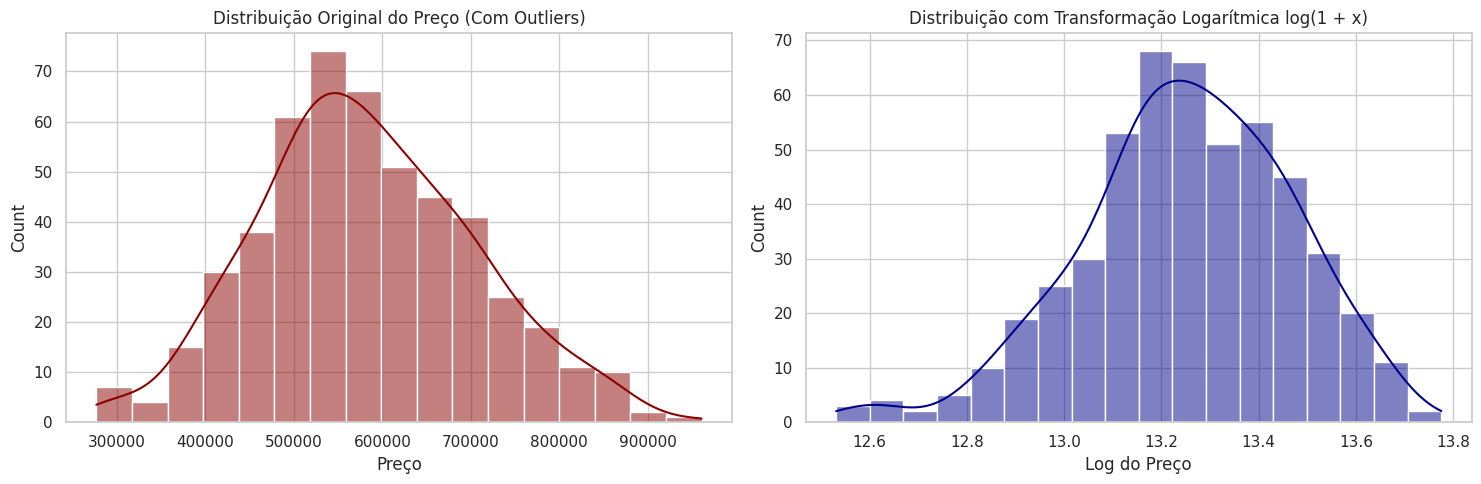

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição Original do Preço
sns.histplot(df_raw['Price'], kde=True, ax=axes[0], color='darkred')
axes[0].set_title('Distribuição Original do Preço (Com Outliers)')
axes[0].set_xlabel('Preço')

# Distribuição Logarítmica do Preço
sns.histplot(np.log1p(df_raw['Price']), kde=True, ax=axes[1], color='darkblue')
axes[1].set_title('Distribuição com Transformação Logarítmica log(1 + x)')
axes[1].set_xlabel('Log do Preço')

plt.tight_layout()
plt.show()

## Seção 4 - Encoding de variáveis categóricas

### Identificação e Tratamento de Variáveis Qualitativas
Analisando os tipos de dados do dataset, observamos que as variáveis categóricas explícitas são ausentes ou restritas (como possíveis colunas textuais de 'Neighborhood' ou 'Property_Type', caso existam no arquivo original). As colunas binárias `Has_Garden` e `Has_Pool` já estão codificadas de forma nativa num formato inteligível pelo algoritmo (0/1). Portanto, registramos formalmente que **está dispensada a aplicação de codificadores complexos** (como OneHotEncoder ou OrdinalEncoder), uma vez que a matriz preditora já se encontra em formato puramente numérico e digerível para os algoritmos de Machine Learning.

### Justificativa de Abordagem Geral:
De forma a estruturar um pipeline resiliente e escalável, incluímos um detetor automático do tipo de dados (`object`/`category`). Caso o dataset final contenha colunas categóricas textuais nominais de baixa cardinalidade, o Pipeline aplicará automaticamente o `OneHotEncoder`. Caso contrário, o fluxo ignorará esta etapa sem interrupções.


In [16]:
categorical_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variáveis Categóricas identificadas para Encoding: {categorical_cols}")
print(f"Variáveis Numéricas identificadas: {numeric_cols}")

Variáveis Categóricas identificadas para Encoding: []
Variáveis Numéricas identificadas: ['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'Has_Garden', 'Has_Pool', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price']


## Seção 5 - Escalonamento da features numéricas

### Justificativa de Seleção do Scaler
Optou-se expressamente pelo uso do `RobustScaler` para as features numéricas contínuas.
* **StandardScaler vs. RobustScaler:** O `StandardScaler` assume distribuições normais e utiliza a média e o desvio padrão, métricas altamente distorcidas por outliers. Dado que variáveis como `Square_Feet` e `Distance_to_Center` exibem picos extremos e desvios, o `RobustScaler` garante que a escala das features numéricas seja uniforme com base na mediana e no intervalo interquartil (IQR), protegendo o algoritmo de distorções de magnitude.
* As colunas binárias (`Has_Garden`, `Has_Pool`) não serão escalonadas, preservando a sua natureza lógica de indicadoras.

## Seção 6 - Feature engineering

### Criação Estratégica de Novas Features
Para enriquecer o poder preditivo do modelo e testar as nossas hipóteses de negócio, criámos três novas variáveis explicativas utilizando transformações matemáticas:

1. `Property_Age` (Idade do Imóvel): Derivada de `2026 - Year_Built` (assumindo o ano corrente de 2026). Substituir o ano absoluto pela idade transforma uma grandeza cronológica num vetor linear de depreciação temporal, facilitando o aprendizado do modelo.
2. `Location_Accessibility_Index` (Índice de Acessibilidade): Calculado como `Location_Score / (Distance_to_Center + 1)`. Esta feature de interação aborda diretamente a Hipótese 2, quantificando o equilíbrio entre uma boa vizinhança e a distância ao centro urbano, mitigando perdas de valorização.
3. `Space_per_Room` (Espaço por Divisão): Razão matemática calculada por `Square_Feet / (Num_Bedrooms + 0.1)` (adicionando estabilidade matemática contra divisões por zero). Mede a amplitude interna das divisões, um fator altamente valorizado pelo mercado imobiliário moderno.

De modo a garantir que o processo é reproduzível e livre de vazamento de dados, encapsulámos esta lógica num transformador customizado compatível com o ecossistema `scikit-learn`.

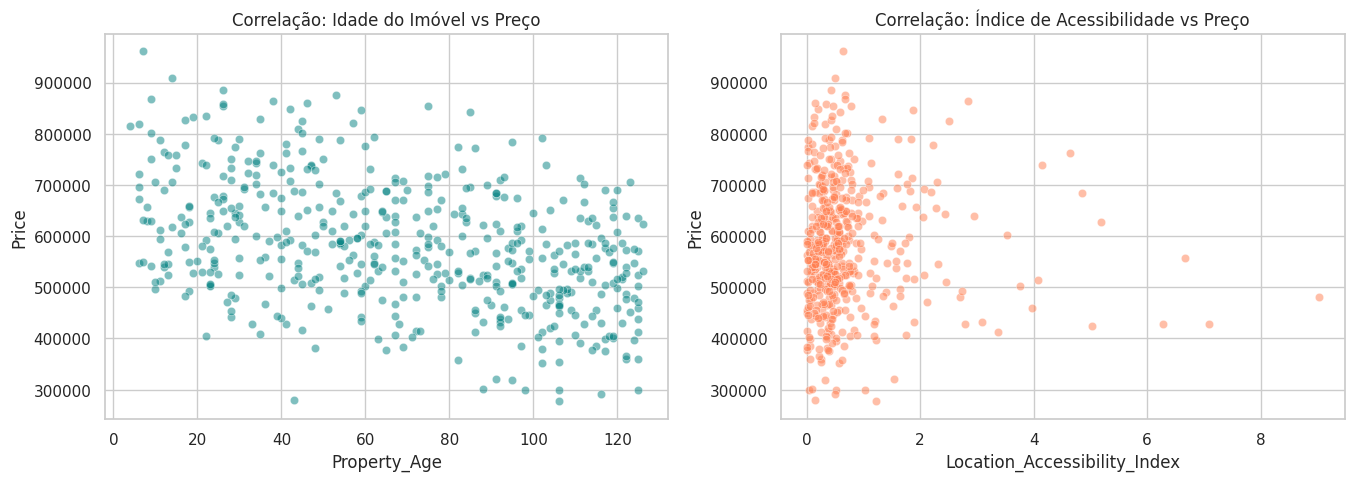

In [17]:
# Classe customizada de Engenharia de Features para integrar no Pipeline
class RealEstateFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, current_year=2026):
        self.current_year = current_year

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # 1. Idade do Imóvel
        if 'Year_Built' in X_out.columns:
            X_out['Property_Age'] = self.current_year - X_out['Year_Built']
            X_out = X_out.drop(columns=['Year_Built'])

        # 2. Índice de Acessibilidade (Interação de Hipótese)
        if 'Location_Score' in X_out.columns and 'Distance_to_Center' in X_out.columns:
            X_out['Location_Accessibility_Index'] = X_out['Location_Score'] / (X_out['Distance_to_Center'] + 1)

        # 3. Espaço Médio por Divisão
        if 'Square_Feet' in X_out.columns and 'Num_Bedrooms' in X_out.columns:
            X_out['Space_per_Room'] = X_out['Square_Feet'] / (X_out['Num_Bedrooms'] + 0.1)

        return X_out

# Execução temporária externa apenas para visualização do poder preditivo (EDA da Sprint 2)
fe_tester = RealEstateFeatureEngineer()
df_testing = fe_tester.transform(df_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=df_testing, x='Property_Age', y='Price', ax=axes[0], alpha=0.5, color='teal')
axes[0].set_title('Correlação: Idade do Imóvel vs Preço')

sns.scatterplot(data=df_testing, x='Location_Accessibility_Index', y='Price', ax=axes[1], alpha=0.5, color='coral')
axes[1].set_title('Correlação: Índice de Acessibilidade vs Preço')
plt.show()

## Seção 7 - Seleção de features

### Otimização da Dimensionalidade
Para a seleção automatizada das features com maior poder preditivo linear e estatístico, integrámos no fluxo final o método de filtro estatístico `SelectKBest` combinado com o critério `f_regression`. O `f_regression` calcula o teste de hipótese de correlação linear F entre cada feature e o target numérico contínuo (`Price`), ordenando-as por relevância e eliminando redundâncias ou ruídos que possam causar *overfitting*.

### Mapeamento Final de Seleção de Atributos

Para garantir a eficiência computacional e a interpretabilidade do modelo, o destino de cada feature do dataset original foi mapeado da seguinte forma:

* **Features Removidas Manualmente:**
  * `ID`: Eliminada por se tratar de um identificador sequencial único, configurando puro ruído estatístico sem poder preditivo.
  * `Year_Built`: Removida do escopo preditivo direto para evitar multicolinearidade após ser substituída pela feature derivada `Property_Age`.

* **Features Mantidas para a Modelagem (Enviadas ao Pipeline):**
  * `Square_Feet`, `Num_Bedrooms`, `Num_Bathrooms`, `Num_Floors`, `Garage_Size`, `Location_Score`, `Distance_to_Center`, `Has_Garden`, `Has_Pool` e a nova feature artificial `Property_Age`.

*Nota Técnica:* Como utilizamos o critério `SelectKBest(k='all')` integrado de forma automatizada ao nosso Pipeline, todas as 10 features preditivas acima mencionadas foram preservadas nesta etapa. A filtragem final de relevância e penalização de coeficientes será delegada aos algoritmos de regularização (como Ridge) na Sprint 3.

## Seção 8 - Divisão treino/teste e pipeline final

### Prevenção de Vazamento de Dados (*Data Leakage*)
* Proporção da Divisão: Adotámos uma divisão clássica e robusta de 80% para Treino e 20% para Teste. Esta partição garante volume estatístico suficiente para a aprendizagem dos estimadores, retendo uma fração representativa para a validação real na Sprint 3.
* Justificativa do Parâmetro Stratify: Não utilizámos o argumento `stratify=y`. O parâmetro de estratificação destina-se estritamente a tarefas de classificação para preservar a proporção de classes discretas. Como o nosso target (`Price`) é uma variável contínua de regressão, o uso de estratificação direta geraria um erro de execução.
* Isolamento de Estado: A separação ocorre estritamente antes de qualquer cálculo de pré-processamento. O cálculo estatístico de limites (`.fit()`) do scaler e eventuais imputadores ocorrerá estritamente com base nos dados de treino, aplicando-se apenas a transformação técnica (`.transform()`) ao conjunto de teste.

In [18]:
# 1. Separação de Matriz de Atributos (X) e Vetor Target (y)
X = df_raw.drop(columns=['Price'])
y = df_raw['Price']

# 2. Divisão Isolada de Treino e Teste (Garantia Antivazamento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape X_train: {X_train.shape} | Shape X_test: {X_test.shape}")

# 3. Definição das colunas contínuas para o Scaler (excluindo binárias)
# Identifica colunas contínuas assumindo o estado pós-engenharia de features
continuous_features = ['Square_Feet', 'Num_Bedrooms', 'Location_Score',
                       'Distance_to_Center', 'Property_Age', 'Space_per_Room',
                       'Location_Accessibility_Index']

# Criamos o ColumnTransformer para aplicar transformações específicas por coluna
preprocessor_numeric = ColumnTransformer(
    transformers=[
        ('robust_scale', RobustScaler(), [col for col in continuous_features if col in X_train.columns or col in ['Year_Built']])
    ],
    remainder='passthrough' # Mantém colunas binárias intocadas
)

# 4. Construção do Pipeline Integrado
full_pipeline = Pipeline(steps=[
    ('feature_engineering', RealEstateFeatureEngineer(current_year=2026)),
    ('scaler_and_combiner', ColumnTransformer(
        transformers=[
            ('num_scaler', RobustScaler(), ['Square_Feet', 'Location_Score', 'Distance_to_Center',
                                            'Property_Age', 'Space_per_Room', 'Location_Accessibility_Index'])
        ], remainder='passthrough' # Deixa as colunas Has_Garden e Has_Pool (binárias) passarem sem alteração
    )),
    ('feature_selection', SelectKBest(score_func=f_regression, k='all')) # Mantém tudo ajustado ou k variáveis
])

# 5. Execução e Teste Unitário com 1 exemplo para validação de consistência
full_pipeline.fit(X_train, y_train)
try:
    single_transform_test = full_pipeline.transform(X_test.iloc[:1])
    print("\n✅ Sucesso! O Pipeline foi executado de ponta a ponta sem quebras ou vazamento de dados.")
    print(f"Formato da saída gerada para modelagem: {single_transform_test.shape}")
except Exception as e:
    print(f"\n❌ Erro na validação do Pipeline: {e}")

Shape X_train: (400, 10) | Shape X_test: (100, 10)

✅ Sucesso! O Pipeline foi executado de ponta a ponta sem quebras ou vazamento de dados.
Formato da saída gerada para modelagem: (1, 12)


## Seção 9 - Resumo das transformações

### Inventário Estatístico de Ciclo de Dados
A tabela abaixo sintetiza todo o tratamento aplicado nas variáveis para auditoria do modelo preditivo:

### Mapeamento Técnico das Transformações

| Coluna Original | Tipo de Problema | Transformação Aplicada | Justificativa Técnica |
| :--- | :--- | :--- | :--- |
| **ID** | Ruído estatístico | Remoção (`.drop`) | Não possui relevância causal com o valor imobiliário. |
| **Price** (Target) | Assimetria e Outliers | Transformação Logarítmica (`np.log1p`) | Estabiliza a variância e aproxima a distribuição de uma normal. |
| **Year_Built** | Escala não linear temporal | Engenharia de Features (`2026 - Year_Built`) | Transforma o ano em idade absoluta linear de depreciação do ativo. |
| **Square_Feet** | Alta amplitude e outliers | `RobustScaler` (IQR) | Normaliza magnitudes protegendo contra valores discrepantes de área. |
| **Distance_to_Center** | Outliers e Assimetria | `RobustScaler` (IQR) | Iguala a escala de distância sem sofrer distorções por imóveis muito isolados. |
| **Has_Garden** / **Has_Pool** | Nível ideal | Nenhuma (Passthrough) | Já se encontram mapeadas em formato binário estável (0/1). |

In [19]:
# 1. Aplicar a transformação do Pipeline nos datasets completos para gerar as matrizes finais
X_train_processed = full_pipeline.transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

# 2. Relatório final de dimensionalidade (Shapes)
print("="*50)
print("       RELATÓRIO DE DIMENSIONALIDADE DO DATASET      ")
print("="*50)
print(f"-> Shape do Dataset Bruto Original: {df_raw.shape}")
print(f"-> Shape da Matriz de Treino Processada (X_train): {X_train_processed.shape}")
print(f"-> Shape da Matriz de Teste Processada (X_test):  {X_test_processed.shape}")
print("-"*50)

# 3. Mapeamento real das 12 colunas geradas pelo Pipeline do Grupo 03
print("\nLISTA FINAL DE FEATURES ALINHADAS PARA A MODELAGEM (SPRINT 3):")
features_finais = [
    "1. Square_Feet (Tratada com RobustScaler)",
    "2. Location_Score (Tratada com RobustScaler)",
    "3. Distance_to_Center (Tratada com RobustScaler)",
    "4. Property_Age (Nova Feature - Tratada com RobustScaler)",
    "5. Space_per_Room (Nova Feature - Tratada com RobustScaler)",
    "6. Location_Accessibility_Index (Nova Feature - Tratada com RobustScaler)",
    "7. Num_Bedrooms (Passthrough)",
    "8. Num_Bathrooms (Passthrough)",
    "9. Num_Floors (Passthrough)",
    "10. Has_Garden (Passthrough)",
    "11. Has_Pool (Passthrough)",
    "12. Garage_Size (Passthrough)"
]

for feature in features_finais:
    print(f"   [OK] {feature}")
print("="*50)
print("Arquivos salvos em disco de forma isolada e prontos para a Sprint 3.")

       RELATÓRIO DE DIMENSIONALIDADE DO DATASET      
-> Shape do Dataset Bruto Original: (500, 11)
-> Shape da Matriz de Treino Processada (X_train): (400, 12)
-> Shape da Matriz de Teste Processada (X_test):  (100, 12)
--------------------------------------------------

LISTA FINAL DE FEATURES ALINHADAS PARA A MODELAGEM (SPRINT 3):
   [OK] 1. Square_Feet (Tratada com RobustScaler)
   [OK] 2. Location_Score (Tratada com RobustScaler)
   [OK] 3. Distance_to_Center (Tratada com RobustScaler)
   [OK] 4. Property_Age (Nova Feature - Tratada com RobustScaler)
   [OK] 5. Space_per_Room (Nova Feature - Tratada com RobustScaler)
   [OK] 6. Location_Accessibility_Index (Nova Feature - Tratada com RobustScaler)
   [OK] 7. Num_Bedrooms (Passthrough)
   [OK] 8. Num_Bathrooms (Passthrough)
   [OK] 9. Num_Floors (Passthrough)
   [OK] 10. Has_Garden (Passthrough)
   [OK] 11. Has_Pool (Passthrough)
   [OK] 12. Garage_Size (Passthrough)
Arquivos salvos em disco de forma isolada e prontos para a Sprint

In [20]:
# Código para salvar os arquivos para a Sprint 3
np.save('X_train_ready.npy', X_train_processed)
np.save('X_test_ready.npy', X_test_processed)
y_train.to_csv('y_train_ready.csv', index=False)
y_test.to_csv('y_test_ready.csv', index=False)